In [1]:
# Flowerden 1989: modelagem de Poisson (dados de contagem): Variáveis extensive
# Flowerden 1992: modelagem pra dados normais: Variáveis intensive

# To force the estimates to
#satisfy the pycnophylactic property, the source zone estimates
#were scaled by a factor equal to the ratio of the observed value
#to the Ž tted value. Estimated counts for each target unit were
#then obtained by adding the estimates of each subunit com-
#posing the target unit. <- this is exactly the correction term!

#pg 643 de Combining_Incompatible_Spatial_Data

In [2]:
import pandas as pd

In [3]:
# Functions that appends a "Type_" suffix on any numeric column
def rename_type(df):
    res = df.rename(
    columns=lambda col: (
        f"Type_{int(pd.to_numeric(col))}"
        if not isinstance(col, bool)
        and pd.notna(pd.to_numeric(col, errors="coerce"))
        and float(pd.to_numeric(col)).is_integer()
        else col
    ))
    return res

In [4]:
import geopandas as gpd
import matplotlib.pyplot as plt
from libpysal.examples import load_example

from tobler.area_weighted import area_interpolate
from tobler.dasymetric import masked_area_interpolate
from tobler.model import glm
from quilt3 import Package

c1 = load_example("Charleston1")
c2 = load_example("Charleston2")

crs = 6569  # https://epsg.io/6569

source_df = gpd.read_file(c1.get_path("sc_final_census2.shp")).to_crs(crs)
target_df = gpd.read_file(c2.get_path("CharlestonMSA2.shp")).to_crs(crs)

#results_dasy = masked_area_interpolate(
#    raster="nlcd_2011.tif",
#    source_df=source_df,
#    target_df=target_df,
#    pixel_values = [21,22,23,24],
#    extensive_variables=["EMP_MALE"],
#)

C:\Users\renan\anaconda3\Lib\site-packages\pyogrio\core.py:36: RuntimeWarning: Could not detect PROJ data files. Set PROJ_LIB environment variable to the correct path.
  _init_proj_data()


In [5]:
# Step 1: Convert raster to vector on source_df
# Step 2: Interpolate source to raster
# Step 3: Count pixels in each source id
# Step 4: Fit the regression

In [6]:
# Internal of masked:

In [7]:
from tobler.dasymetric.raster_tools import extract_raster_features

In [8]:
from tobler.dasymetric import _fast_append_profile_in_gdf

In [9]:
raster_mask = extract_raster_features(source_df, "nlcd_2011.tif", pixel_values = [21,22,23,24], collapse_values=False)

In [10]:
raster_mask.columns

Index(['value', 'geometry'], dtype='object')

In [11]:
raster_mask.shape

(127687, 2)

In [12]:
raster_mask['value'].value_counts()

value
21.0    60522
22.0    41024
23.0    19865
24.0     6276
Name: count, dtype: int64

<Axes: >

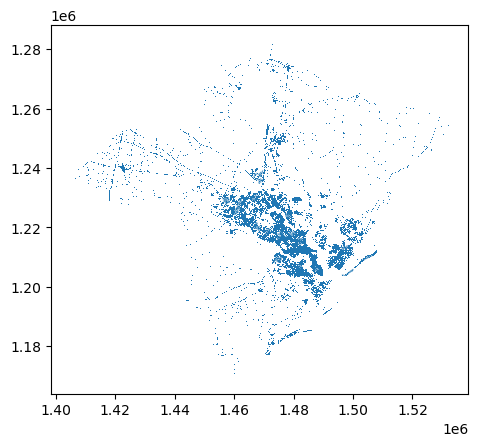

In [13]:
raster_mask.plot()

In [14]:
# Same CRS
raster_mask = raster_mask.to_crs(source_df.crs)

source_df = source_df.copy()
source_df["source_id"] = source_df.index

target_df = target_df.copy()
target_df["target_id"] = target_df.index

raster_mask = raster_mask.copy()
raster_mask["mask_id"] = raster_mask.index

variable = 'EMP_MALE'


# Intersect the two layers (source + raster)
source_intersections = gpd.overlay(
    raster_mask[["mask_id", "value", "geometry"]],
    source_df[["source_id", "geometry"]],
    how="intersection"
).dissolve("mask_id").reset_index()

# Count how many intersected pieces of each category fall in each source polygon
source_counts = (
    source_intersections.groupby(["source_id", "value"])
                 .size()
                 .unstack(fill_value=0)
                 .reset_index()
)

source_result = source_df.merge(source_counts, on="source_id", how="left").fillna(0)

In [15]:
source_result = rename_type(source_result)
source_result.head(1)

,FIPS,MSA,TOT_POP,POP_16,POP_65,WHITE_,BLACK_,ASIAN_,HISP_,MULTI_RA,...,POV_POP,POV_TOT,HSG_VAL,POLYID,geometry,source_id,Type_21,Type_22,Type_23,Type_24
0,45015020200,Charlesto,7665,2083,983,2101,5427,30,54,38,...,7520,1908,52300,0,"POLYGON ((725360.513 166693.212, 725312.593 16...",0,1798,1349,433,171


In [16]:
import numpy as np
#formula = ("EMP_MALE ~ -1 + np.log1p(Type_21) + np.log1p(Type_22) + np.log1p(Type_23) + np.log1p(Type_24)")
formula = ("EMP_MALE ~ -1 + Type_21 + Type_22 + Type_23 + Type_24")
import statsmodels.formula.api as smf
import statsmodels.api as sm
#results_regression = smf.poisson(formula, data=source_result).fit()
model = smf.glm(formula, data=source_result, family=sm.families.Poisson())

In [17]:
results_regression = model.fit()
print(results_regression.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:               EMP_MALE   No. Observations:                  117
Model:                            GLM   Df Residuals:                      113
Model Family:                 Poisson   Df Model:                            3
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -4.9852e+05
Date:                Fri, 10 Apr 2026   Deviance:                   9.9603e+05
Time:                        15:40:29   Pearson chi2:                 3.20e+07
No. Iterations:                    18   Pseudo R-squ. (CS):               -inf
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Type_21        0.0013   1.17e-05    110.215      0.0

C:\Users\renan\anaconda3\Lib\site-packages\statsmodels\genmod\generalized_linear_model.py:1891: RuntimeWarning: overflow encountered in exp
  prsq = 1 - np.exp((self.llnull - self.llf) * (2 / self.nobs))


In [18]:
# You have to extract the log from predict in order to get the weights sums!!
source_result['predito'] = np.log(results_regression.predict(source_result.fillna(0)))

In [19]:
source_result.head(2)

,FIPS,MSA,TOT_POP,POP_16,POP_65,WHITE_,BLACK_,ASIAN_,HISP_,MULTI_RA,...,POV_TOT,HSG_VAL,POLYID,geometry,source_id,Type_21,Type_22,Type_23,Type_24,predito
0,45015020200,Charlesto,7665,2083,983,2101,5427,30,54,38,...,1908,52300,0,"POLYGON ((725360.513 166693.212, 725312.593 16...",0,1798,1349,433,171,7.318901
1,45015020100,Charlesto,7291,1501,739,2899,4259,24,26,62,...,1588,62700,1,"POLYGON ((699159.417 163364.008, 699123.312 16...",1,1928,1024,66,9,5.783450


In [20]:
source_intersections_2 = source_intersections.\
    merge(source_result[['source_id', variable, 'predito']], 
          on="source_id", 
          how="left").\
    fillna(0)

In [21]:
source_intersections_2.head()

,mask_id,geometry,value,source_id,EMP_MALE,predito
0,0,"MULTIPOLYGON (((705948.617 184158.696, 705954....",22.0,0,1177,7.318901
1,1,"POLYGON ((705944.621 184159.326, 705945.04 184...",23.0,0,1177,7.318901
2,2,"POLYGON ((705984.058 184153.106, 705974.503 18...",21.0,0,1177,7.318901
3,3,"POLYGON ((705939.904 184069.568, 705935.127 18...",23.0,0,1177,7.318901
4,4,"POLYGON ((705944.682 184098.982, 705939.904 18...",22.0,0,1177,7.318901


In [22]:
# Match each pixel to its corresponding weight

coefs = results_regression.params

# keep only Type_* coefficients
type_coefs = coefs[coefs.index.str.match(r"^Type_\d+$")]

In [23]:
type_coefs

Type_21    0.001289
Type_22    0.003144
Type_23    0.000904
Type_24    0.002155
dtype: float64

In [24]:
# build mapping: 21 -> coef(Type_21), 22 -> coef(Type_22), ...
mapping = {
    int(name.split("_", 1)[1]): coef
    for name, coef in type_coefs.items()
}

# add coefficient as a new column
source_intersections_2["type_coef"] = source_intersections_2["value"].map(mapping)

In [25]:
source_intersections_2.head()

,mask_id,geometry,value,source_id,EMP_MALE,predito,type_coef
0,0,"MULTIPOLYGON (((705948.617 184158.696, 705954....",22.0,0,1177,7.318901,0.003144
1,1,"POLYGON ((705944.621 184159.326, 705945.04 184...",23.0,0,1177,7.318901,0.000904
2,2,"POLYGON ((705984.058 184153.106, 705974.503 18...",21.0,0,1177,7.318901,0.001289
3,3,"POLYGON ((705939.904 184069.568, 705935.127 18...",23.0,0,1177,7.318901,0.000904
4,4,"POLYGON ((705944.682 184098.982, 705939.904 18...",22.0,0,1177,7.318901,0.003144


In [26]:
source_intersections_2['pixel_pop_est'] = source_intersections_2['type_coef'] * (source_intersections_2['EMP_MALE'] / source_intersections_2['predito'])

In [27]:
source_intersections_2.head()

,mask_id,geometry,value,source_id,EMP_MALE,predito,type_coef,pixel_pop_est
0,0,"MULTIPOLYGON (((705948.617 184158.696, 705954....",22.0,0,1177,7.318901,0.003144,0.505647
1,1,"POLYGON ((705944.621 184159.326, 705945.04 184...",23.0,0,1177,7.318901,0.000904,0.145453
2,2,"POLYGON ((705984.058 184153.106, 705974.503 18...",21.0,0,1177,7.318901,0.001289,0.207247
3,3,"POLYGON ((705939.904 184069.568, 705935.127 18...",23.0,0,1177,7.318901,0.000904,0.145453
4,4,"POLYGON ((705944.682 184098.982, 705939.904 18...",22.0,0,1177,7.318901,0.003144,0.505647


In [28]:
# Sum the weights for each source polygon to get the estimated population
sum_by_source = (
    source_intersections_2.groupby("source_id", as_index=False)["pixel_pop_est"]
      .sum()
)

In [29]:
sum_by_source.head()

,source_id,pixel_pop_est
0,0,1177.0
1,1,1171.0
2,2,1860.0
3,3,1180.0
4,4,880.0


In [30]:
sum_by_source['pixel_pop_est'].sum()

np.float64(128317.0)

In [31]:
source_result['EMP_MALE'].sum()

np.int64(128317)

In [32]:
# Intersect the two layers (target + raster)

idx_name = target_df.index.name if target_df.index.name else "idx"
target_df[idx_name] = target_df.index

target_intersections = gpd.overlay(
    raster_mask[["mask_id", "value", "geometry"]],
    target_df[["target_id", "geometry"]],
    how="intersection"
).dissolve("mask_id").reset_index()

In [33]:
target_intersections.head()

,mask_id,geometry,value,target_id
0,0,"MULTIPOLYGON (((705948.201 184158.762, 705954....",22.0,0
1,1,"POLYGON ((705944.676 184159.318, 705945.04 184...",23.0,0
2,2,"POLYGON ((705984.058 184153.106, 705974.503 18...",21.0,0
3,3,"POLYGON ((705939.904 184069.568, 705935.127 18...",23.0,0
4,4,"POLYGON ((705944.682 184098.982, 705939.904 18...",22.0,0


In [34]:
# Esse merge pode ter duplicação!!!
target_intersections_2 = target_intersections.\
    merge(source_intersections_2[['mask_id', 'pixel_pop_est']], 
          on="mask_id", 
          how="inner")

In [35]:
source_intersections_2['pixel_pop_est'].sum()

np.float64(128317.0)

In [36]:
target_intersections_2['pixel_pop_est'].sum()

np.float64(126354.64914283706)

In [37]:
# Esse merge pode ter duplicação!!!
target_intersections_3 = target_intersections_2.drop_duplicates(subset=['mask_id'])

In [38]:
target_intersections_3['pixel_pop_est'].sum()

np.float64(126354.64914283706)

In [39]:
target_intersections_3.shape

(125971, 5)

In [40]:
target_intersections_2.head()

,mask_id,geometry,value,target_id,pixel_pop_est
0,0,"MULTIPOLYGON (((705948.201 184158.762, 705954....",22.0,0,0.505647
1,1,"POLYGON ((705944.676 184159.318, 705945.04 184...",23.0,0,0.145453
2,2,"POLYGON ((705984.058 184153.106, 705974.503 18...",21.0,0,0.207247
3,3,"POLYGON ((705939.904 184069.568, 705935.127 18...",23.0,0,0.145453
4,4,"POLYGON ((705944.682 184098.982, 705939.904 18...",22.0,0,0.505647


In [41]:
# Sum the weights for each source polygon to get the estimated population
sum_by_target = (
    target_intersections_3.groupby("target_id", as_index=False)["pixel_pop_est"]
      .sum()
)

In [42]:
sum_by_target.head()

,target_id,pixel_pop_est
0,0,1053.523350
1,1,433.316211
2,2,48.449891
3,3,54.210436
4,4,1119.861996


In [43]:
sum_by_target['pixel_pop_est'].sum()

np.float64(126354.64914283705)

In [44]:
target_df_final = target_df.\
    merge(sum_by_target, 
          on="target_id", 
          how="inner")

In [45]:
target_df.shape

(42, 62)

<Axes: >

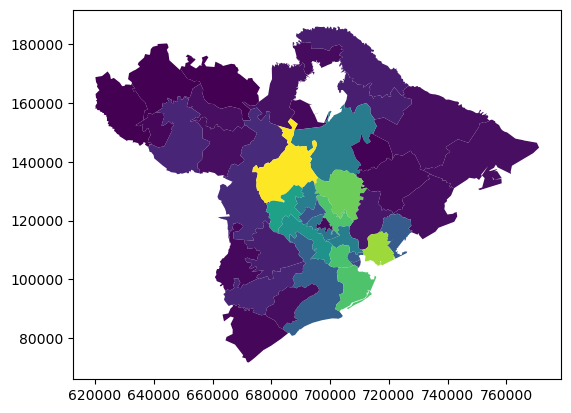

In [46]:
target_df_final.plot(column="pixel_pop_est", cmap="viridis")

In [47]:
print(source_df["EMP_MALE"].sum())
print(target_df_final["pixel_pop_est"].sum())

128317
126354.64914283705


In [50]:
128317 - 126354

1963

In [49]:
#results['EMP_MALE'].sum() # 126432
#tracts['EMP_MALE'].sum() # 128317

In [ ]:
source_result['predito'].sum()

In [ ]:
#  create a column in the source_df to dissolve on
idx_name = source_df.index.name if source_df.index.name else "idx"
source_df[idx_name] = source_df.index

#  clip source_df by its mask (overlay/dissolve is faster than gpd.clip here)
source_df = gpd.overlay(source_df, raster_mask.to_crs(source_df.crs), how="intersection").dissolve(idx_name)

In [ ]:
source_df.plot()

In [ ]:
source_df.head(1)

In [ ]:
source_df.head(1).plot()

In [ ]:
# ChatGPT

import geopandas as gpd
import pandas as pd

# Same CRS
raster_mask = raster_mask.to_crs(source_df.crs)

source_df = source_df.copy()
source_df["source_id"] = source_df.index
raster_mask = raster_mask.copy()
raster_mask["mask_id"] = raster_mask.index

# Intersect the two layers
intersections = gpd.overlay(
    raster_mask[["mask_id", "value", "geometry"]],
    source_df[["source_id", "geometry"]],
    how="intersection"
)

# Count how many intersected pieces of each category fall in each source polygon
counts = (
    intersections.groupby(["source_id", "value"])
                 .size()
                 .unstack(fill_value=0)
                 .reset_index()
)

result = source_df.merge(counts, on="source_id", how="left").fillna(0)

In [ ]:
result.head()

In [ ]:
result_renamed = result.rename(
    columns=lambda col: (
        f"Type_{int(pd.to_numeric(col))}"
        if not isinstance(col, bool)
        and pd.notna(pd.to_numeric(col, errors="coerce"))
        and float(pd.to_numeric(col)).is_integer()
        else col
    )
)

In [ ]:
result_renamed.head(1)

In [ ]:
raster_codes = [21,22,23,24]
raster_codes = ["Type_" + str(i) for i in raster_codes]

#formula = (
#            "EMP_MALE"
#            + "~ -1 +"
#            + "+".join(["np.log1p(" + code + ")" for code in raster_codes])
#        )
formula = ("EMP_MALE ~ Type_21 + Type_22 + Type_23 + Type_24")
import statsmodels.formula.api as smf
results_regression = smf.poisson(formula, data=result_renamed).fit()
formula

In [ ]:
import statsmodels.formula.api as smf
results_regression = smf.poisson(formula, data=result_renamed).fit()

In [ ]:
results_regression.summary()

In [ ]:
source_out = result_renamed[[result_renamed.geometry.name, 'EMP_MALE']]
source_out['predito'] = results_regression.predict(result_renamed.drop(columns=[result_renamed.geometry.name]).fillna(0))

In [ ]:
result_renamed['EMP_MALE'].sum()

In [ ]:
source_out['predito'].sum()

In [ ]:
source_out.columns

In [ ]:
source_out.head()

In [ ]:
source_out['rescale_EMP_MALE'] = source_out['EMP_MALE'] * (source_out['EMP_MALE']/source_out['predito'])

In [ ]:
source_out.head()

In [ ]:
source_out.head()

In [ ]:
source_out['EMP_MALE'].sum()

In [ ]:
source_out['predito'].sum()

In [ ]:
source_out['rescale_EMP_MALE'].sum()

In [ ]:
result_renamed.

In [ ]:
intersections.plot()

In [ ]:
intersections.head()

In [ ]:
target_df = zip_codes

target_df = target_df.copy()
target_df["target_id"] = target_df.index


# Intersect the two layers
target_intersections = gpd.overlay(
    raster_mask[["mask_id", "value", "geometry"]],
    target_df[["target_id", "geometry"]],
    how="intersection"
)

# Count how many intersected pieces of each category fall in each source polygon
target_counts = (
    target_intersections.groupby(["target_id", "value"])
                 .size()
                 .unstack(fill_value=0)
                 .reset_index()
)

target_result = target_df.merge(target_counts, on="target_id", how="left").fillna(0)

In [ ]:
target_result.head()

In [ ]:
target_intersections.plot()

In [ ]:
target_result_renamed = target_result.rename(
    columns=lambda col: (
        f"Type_{int(pd.to_numeric(col))}"
        if not isinstance(col, bool)
        and pd.notna(pd.to_numeric(col, errors="coerce"))
        and float(pd.to_numeric(col)).is_integer()
        else col
    )
)

In [ ]:
target_result_renamed.head()

In [ ]:
out = target_result_renamed[[target_result_renamed.geometry.name]]
out['predito'] = results_regression.predict(target_result_renamed.drop(columns=[target_result_renamed.geometry.name]).fillna(0))

In [ ]:
target_result_renamed['EMP_MALE']

In [ ]:
out.head()

In [ ]:
out['predito'].sum()

In [ ]:
tracts['EMP_MALE'].sum()

In [ ]:
92400/128317

In [ ]:
raster_mask.shape

In [ ]:
profiled_df = _fast_append_profile_in_gdf(
        tracts, "nlcd_2011.tif"
    )

In [ ]:
profiled_df.head()

In [ ]:
profiled_df.plot()

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
from libpysal.examples import load_example

from tobler.area_weighted import area_interpolate
from tobler.dasymetric import masked_area_interpolate
from tobler.model import glm
from quilt3 import Package

c1 = load_example("Charleston1")
c2 = load_example("Charleston2")

crs = 6569  # https://epsg.io/6569

tracts = gpd.read_file(c1.get_path("sc_final_census2.shp")).to_crs(crs)
zip_codes = gpd.read_file(c2.get_path("CharlestonMSA2.shp")).to_crs(crs)


results_area = area_interpolate(
    source_df=tracts,
    target_df=zip_codes,
    extensive_variables=["EMP_MALE"],
)


results_dasy = masked_area_interpolate(
    raster="nlcd_2011.tif",
    source_df=tracts,
    target_df=zip_codes,
    pixel_values = [21,22,23,24],
    extensive_variables=["EMP_MALE"],
)
print(tracts['EMP_MALE'].sum())
print(results_area['EMP_MALE'].sum())
print(results_dasy['EMP_MALE'].sum())

In [ ]:
results_area.head()

In [ ]:
results_dasy.head()

In [ ]:
- Fast append profile
- Fit the regression
- Adjust before to return the pixel types and use the extract_raster_features
- Apply correction term for each pixel

In [ ]:
import statsmodels.formula.api as smf
from statsmodels.genmod.families import Gaussian, NegativeBinomial, Poisson

In [ ]:
source_df = tracts
variable = 'EMP_MALE'
raster = 'nlcd_2011.tif'
raster_codes = [21,22,23,24]
force_crs_match = True
liks = {"poisson": Poisson, "gaussian": Gaussian, "neg_binomial": NegativeBinomial}
likelihood="poisson"

In [ ]:
str_codes = [str(i) for i in raster_codes]

formula = (
        variable + " ~ -1 + " + " + ".join(["Type_" + s for s in str_codes])
    )

In [ ]:
profiled_df = _fast_append_profile_in_gdf(
        source_df[[source_df.geometry.name, variable]], raster, force_crs_match
    )

results = smf.glm(formula, data=profiled_df, family=liks[likelihood]()).fit()

In [ ]:
raster_mask = extract_raster_features(tracts, "nlcd_2011.tif", pixel_values = [21,22,23,24], collapse_values=False)

In [ ]:
raster_mask.plot()

In [ ]:
raster_mask.head()